# PLAN 08 Step 13 overlap-comparison notebook

This notebook records the current PLAN 08 status after the interface refactor.


## Current status

The earlier interface mismatch has been removed.

Previously, Step 13 was phrased through

```lean
HighEscapingChartChainProductComparisonData
```

which uses an all-level object

```lean
BasinLoopChartChainMonodromyData c z₀.
```

For `c = 2`, the literal all-level constructor

```lean
BasinLoopChartChainMonodromyData.of_nonzero_values_two
```

is not usable in general because its nonvanishing hypothesis is false at `z₀ = 0`.

This is now handled by the high-escaping wrappers:

```lean
HighEscapingActualChartChainsEventuallyEqAtOverlapsData
HighEscapingActualChartChainsLocalLogsRestrictGlobalData
HighEscapingActualChartChainsProductComparisonData
HighEscapingActualChartChainsProductComparisonData.toAllLevelProductComparisonData
```


## The remaining obstruction

The obstruction is now purely at the level of the **actual theorem to prove**.

We still do **not** have a construction of the actual high-level chart family together with the comparison data needed to identify its monodromy product with the canonical one-chart product.

Equivalently, the missing input is one of the following:

1. a construction of

   ```lean
   HighEscapingActualChartChainsEventuallyEqAtOverlapsData
   ```

   for the actual high-escaping chains; or

2. a stronger construction of

   ```lean
   HighEscapingActualChartChainsLocalLogsRestrictGlobalData
   ```

   showing that all local logs in the actual high chain come from one global logarithm branch.

At present, neither package has been built for the actual chain family.


## Exact proof target

Fix a basin basepoint `z₀`, a loop `γ : BasinLoop (2 : ℂ) z₀`, and a requested lower level `N`.
Let

```lean
K := E.levelAbove γ N
```

be the chosen escaping level supplied by

```lean
E : ArbitrarilyHighEscapingLevelBasinLoopChartChainData (2 : ℂ) z₀.
```

The canonical comparison chain at level `K` already exists:

```lean
E.chainAbove γ N : BasinLoopChartChain (2 : ℂ) K z₀ γ
```

and its product is already proved trivial:

```lean
(E.chainAbove γ N).monodromyProduct = 1.
```

The missing theorem is to construct an **actual** chain

```lean
actualChain N γ : BasinLoopChartChain (2 : ℂ) K z₀ γ
```

and then prove either:

```lean
ChartChainLocalLogsEventuallyEqAtOverlaps (actualChain N γ)
```

or the stronger global-log restriction statement for `actualChain N γ`.

Once that is done, the formalized theorem yields

```lean
(actualChain N γ).monodromyProduct = 1,
```

hence the required high-level product comparison.


## Exact theorem to prove

> **Theorem (PLAN 08 Step 13, high-escaping comparison theorem).**  
> Let $z_0 \in \mathcal B_\infty(2)$, let $\gamma$ be a loop in $\mathcal B_\infty(2)$ based at $z_0$, and let $N \geq 0$ be a requested lower level. Choose a sufficiently large escaping level $K \geq N$ such that the full level-$K$ loop image lies in the exterior region where the near-infinity logarithmic coordinate is already defined.
> 
> Let $\Gamma_K$ denote the corresponding level-$K$ image curve in the $w$-plane. Then there exists a finite consecutive simply-connected open cover
> 
> $$
> U_1,\dots,U_m \subset \mathbf C^*
> $$
> 
> of $\Gamma_K$ with the following properties:
> 
> 1. on each $U_j$ there is a holomorphic logarithm branch $b_j^{\mathrm{act}}$ coming from the **actual** high-level continuation construction;
> 2. on each $U_j$ there is a holomorphic logarithm branch $b_j^{\mathrm{can}}$ coming from the **canonical one-chart** continuation at level $K$;
> 3. the two systems are normalized by the same initial germ at the starting point of the loop;
> 4. for every consecutive overlap $U_j \cap U_{j+1}$, the branches $b_j^{\mathrm{act}}$ and $b_j^{\mathrm{can}}$ agree on a neighborhood of every overlap point of $\Gamma_K$.
> 
> Consequently, the two holomorphic continuation procedures determine the same terminal logarithm value after one turn around the loop, and hence the same endpoint multiplier. Since the canonical one-chart continuation has trivial multiplier, the actual high-level continuation also has trivial multiplier.

Equivalently: the remaining Step 13 theorem is to prove that, at sufficiently high escaping levels, the actual branch system and the canonical branch system define the **same holomorphic continuation along the loop image**.

A stronger sufficient statement would be to prove that all actual local logarithm branches at the chosen high escaping level are restrictions of a single holomorphic logarithm branch on one common zero-free domain containing the whole image curve. In that stronger situation, the overlap-agreement conclusion is immediate.

## Easy numerical toy model in the style of the main PLAN 08 notebook

Step 13 remains open because the local branch comparison has not yet been packaged and proved for the actual high-level chains.

A simple positive model is obtained from

$$
f(z)=z^2+2,
\qquad
\gamma(t)=\tfrac12 e^{2\pi i t},
\qquad
A_2(z)=f^2(z)=z^4+4z^2+6.
$$

For this small loop, the high-level image $A_2(\gamma([0,1]))$ stays in the right half-plane, so one global logarithm branch exists there. This gives a model for the branch-comparison statement needed for the actual high-level chains.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

def f(z):
    return z**2 + 2

def gamma(t, r=0.5):
    return r * np.exp(2j * np.pi * t)

def A2(z):
    return f(f(z))

ts = np.linspace(0.0, 1.0, 1400)
z_curve = gamma(ts)
w_curve = A2(z_curve)

cont_arg = np.unwrap(np.angle(w_curve))
log_curve = np.log(np.abs(w_curve)) + 1j * cont_arg
endpoint_multiplier = np.exp(1j * (cont_arg[-1] - cont_arg[0]))
zero_radius = 6 ** 0.25

def tube_patch(points, radius=0.18, color='#9ecae1', alpha=0.35):
    pts = np.asarray(points, dtype=np.complex128)
    tangents = np.gradient(pts)
    tangents = np.where(np.abs(tangents) < 1e-12, 1 + 0j, tangents)
    normals = 1j * tangents / np.abs(tangents)
    upper = pts + radius * normals
    lower = pts - radius * normals
    polygon = np.concatenate([upper, lower[::-1]])
    return Polygon(
        np.column_stack([polygon.real, polygon.imag]),
        closed=True,
        facecolor=color,
        edgecolor='none',
        alpha=alpha,
    )

print(f'sampled min Re A_2 = {w_curve.real.min():.8f}')
print(f'sampled min |A_2| = {np.abs(w_curve).min():.8f}')
print(f'endpoint multiplier = {endpoint_multiplier.real:.8f} + {endpoint_multiplier.imag:.8f}i')


sampled min Re A_2 = 5.06250189
sampled min |A_2| = 5.06250227
endpoint multiplier = 1.00000000 + -0.00000000i


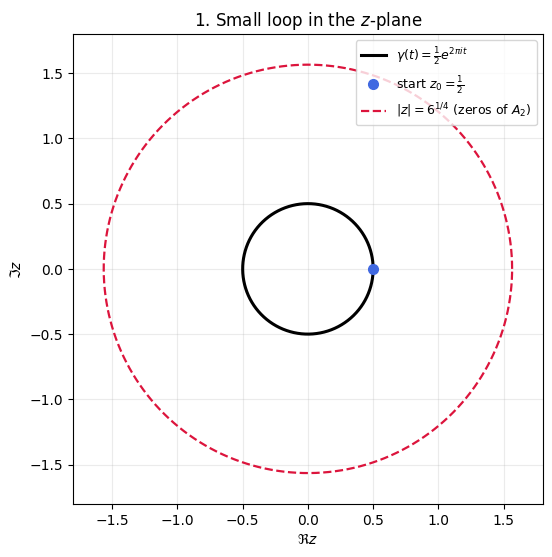

In [2]:
fig, ax = plt.subplots(figsize=(6.1, 6.1))
theta = np.linspace(0, 2 * np.pi, 600)
ax.plot(z_curve.real, z_curve.imag, color='black', lw=2.2, label=r'$\gamma(t)=\frac{1}{2} e^{2\pi i t}$')
ax.plot(gamma(0).real, gamma(0).imag, 'o', ms=7, color='royalblue', label=r'start $z_0=\frac{1}{2}$')
ax.plot(zero_radius * np.cos(theta), zero_radius * np.sin(theta), '--', color='crimson', lw=1.6,
        label=r'$|z|=6^{1/4}$ (zeros of $A_2$)')
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_xlabel(r'$\Re z$')
ax.set_ylabel(r'$\Im z$')
ax.set_title(r'1. Small loop in the $z$-plane')
ax.legend(loc='upper right', fontsize=9)
plt.show()


#### 1. The loop in the $z$-plane

This loop is much smaller than the radius $6^{1/4}$ on which the zeros of $A_2(z)=z^4+4z^2+6$ lie. So unlike the winding example in the main PLAN 08 notebook, this toy loop does **not** force any global logarithm obstruction.


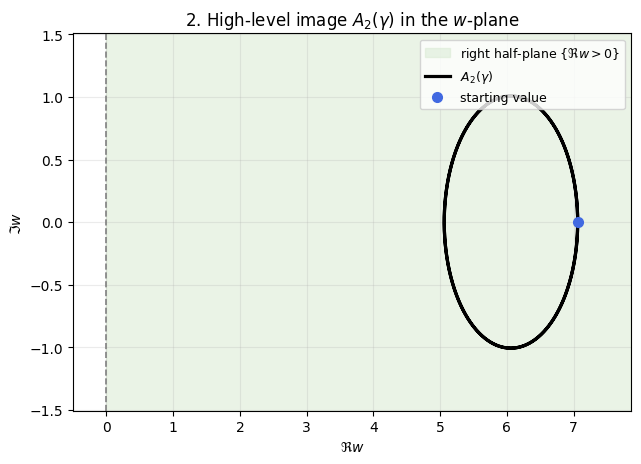

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.9))
xmax = float(w_curve.real.max() + 0.8)
ax.axvspan(0, xmax, color='#d9ead3', alpha=0.55, label=r'right half-plane $\{\Re w > 0\}$')
ax.axvline(0, color='gray', lw=1.2, ls='--')
ax.plot(w_curve.real, w_curve.imag, color='black', lw=2.3, label=r'$A_2(\gamma)$')
ax.plot(w_curve[0].real, w_curve[0].imag, 'o', ms=7, color='royalblue', label='starting value')
ax.set_xlim(-0.5, xmax)
ax.set_ylim(w_curve.imag.min() - 0.5, w_curve.imag.max() + 0.5)
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
ax.set_title(r'2. High-level image $A_2(\gamma)$ in the $w$-plane')
ax.legend(loc='upper right', fontsize=9)
plt.show()


#### 2. One global log domain already exists

Numerically, the whole image curve stays inside the right half-plane. Hence the principal logarithm is a single holomorphic branch on one open set containing the full curve. In this toy model, the comparison between the actual and canonical branches is easy because both can be realized as restrictions of that one logarithm branch.


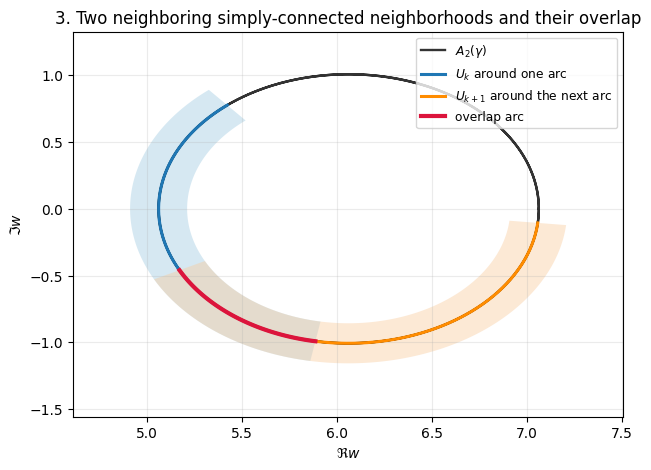

In [4]:
seg1 = w_curve[240:520]
seg2 = w_curve[410:690]
overlap = w_curve[410:520]

fig, ax = plt.subplots(figsize=(7.1, 5.0))
ax.plot(w_curve.real, w_curve.imag, color='black', lw=1.7, alpha=0.8, label=r'$A_2(\gamma)$')
ax.add_patch(tube_patch(seg1, radius=0.15, color='#9ecae1', alpha=0.42))
ax.add_patch(tube_patch(seg2, radius=0.15, color='#f9cb9c', alpha=0.42))
ax.plot(seg1.real, seg1.imag, color='tab:blue', lw=2.2, label=r'$U_k$ around one arc')
ax.plot(seg2.real, seg2.imag, color='darkorange', lw=2.2, label=r'$U_{k+1}$ around the next arc')
ax.plot(overlap.real, overlap.imag, color='crimson', lw=3.0, label=r'overlap arc')
xmin = min(seg1.real.min(), seg2.real.min()) - 0.45
xmax = max(seg1.real.max(), seg2.real.max()) + 0.45
ymin = min(seg1.imag.min(), seg2.imag.min()) - 0.55
ymax = max(seg1.imag.max(), seg2.imag.max()) + 0.55
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
ax.set_title(r'3. Two neighboring simply-connected neighborhoods and their overlap')
ax.legend(loc='upper right', fontsize=8.8)
plt.show()


#### 3. The local overlap statement that Step 13 needs

The red arc represents the kind of consecutive overlap on which Step 13 must compare local branches. In the toy model, both local branches come from the same principal logarithm on the right half-plane, so they agree automatically on a neighborhood of every overlap value.

That is exactly the shape of the formal hypothesis

```lean
ChartChainLocalLogsEventuallyEqAtOverlaps
```

for the actual high-level chain.


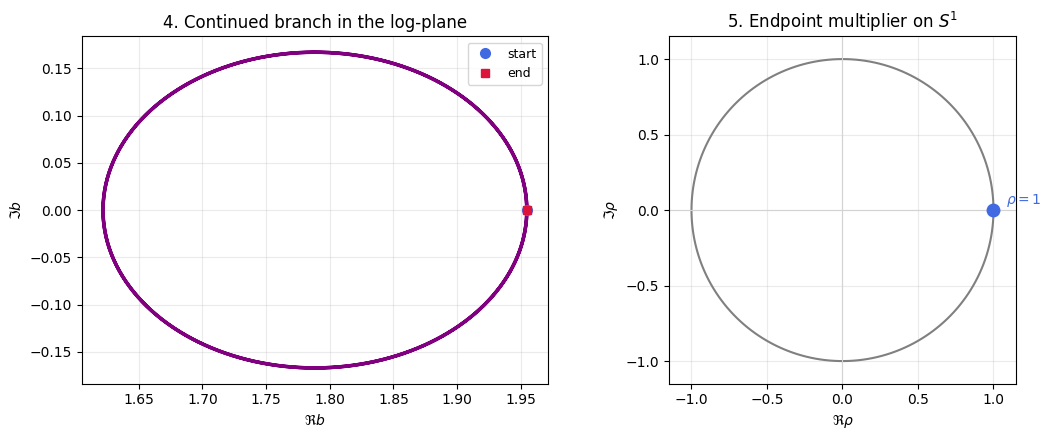

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5))

ax = axes[0]
ax.plot(log_curve.real, log_curve.imag, color='purple', lw=2.5)
ax.plot(log_curve[0].real, log_curve[0].imag, 'o', ms=7, color='royalblue', label='start')
ax.plot(log_curve[-1].real, log_curve[-1].imag, 's', ms=6, color='crimson', label='end')
ax.set_xlabel(r'$\Re b$')
ax.set_ylabel(r'$\Im b$')
ax.set_title(r'4. Continued branch in the log-plane')
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), color='gray', lw=1.5)
ax.axhline(0, color='lightgray', lw=0.8)
ax.axvline(0, color='lightgray', lw=0.8)
ax.plot(endpoint_multiplier.real, endpoint_multiplier.imag, 'o', ms=9, color='royalblue')
ax.text(endpoint_multiplier.real + 0.08, endpoint_multiplier.imag + 0.04, r'$\rho = 1$', color='royalblue', fontsize=10)
ax.set_aspect('equal')
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_title(r'5. Endpoint multiplier on $S^1$')
ax.set_xlabel(r'$\Re \rho$')
ax.set_ylabel(r'$\Im \rho$')

plt.tight_layout()
plt.show()


#### 4. Scope of this toy model

In this example, the endpoint multiplier is $1$ because the whole high-level image lies in one logarithm domain. The comparison theorem is therefore immediate: the actual and canonical branches are restrictions of the same holomorphic logarithm.

The remaining Step 13 work is to prove an analogous statement for the actual high-escaping chart chains when one global chart is not available in advance. The theorem infrastructure is already in place; the missing part is the construction of the local branches and the proof of their overlap agreement.


## More general numerical family: circles $\gamma_r(t)=r e^{2\pi i t}$

The single loop $\gamma(t)=\tfrac12 e^{2\pi i t}$ is only the easiest case. A more informative positive example is the **family of circles**

$$
\gamma_r(t)=r e^{2\pi i t}, \qquad 0 \le t \le 1.
$$

For

$$
A_2(z)=z^4+4z^2+6,
$$

a direct estimate gives

$$
\operatorname{Re} A_2(\gamma_r(t)) \ge 6-4r^2-r^4.
$$

Hence every radius satisfying

$$
6-4r^2-r^4>0
$$

forces the whole high-level image $A_2(\gamma_r([0,1]))$ into the right half-plane. This gives an **open family** of loops on which the high-level comparison theorem is easy: both the actual and canonical branches can be restrictions of one holomorphic logarithm branch.

In [6]:
r_crit = float(np.sqrt(-2 + np.sqrt(10)))
r_values = np.linspace(0.15, min(1.05, r_crit - 0.01), 90)
right_half_lower_bound = 6 - 4 * r_values**2 - r_values**4
min_re_sampled = []
min_abs_sampled = []

for r in r_values:
    z_r = gamma(ts, r)
    w_r = A2(z_r)
    min_re_sampled.append(w_r.real.min())
    min_abs_sampled.append(np.abs(w_r).min())

min_re_sampled = np.array(min_re_sampled)
min_abs_sampled = np.array(min_abs_sampled)
representative_r = [0.25, 0.55, 0.85, 1.02]
representative_curves = [(r, A2(gamma(ts, r))) for r in representative_r]

print(f'critical radius r_crit ≈ {r_crit:.8f}')
print(f'min sampled lower bound on chosen interval = {right_half_lower_bound.min():.8f}')
print(f'min sampled Re(A_2) on chosen interval = {min_re_sampled.min():.8f}')
print(f'min sampled |A_2| on chosen interval = {min_abs_sampled.min():.8f}')

critical radius r_crit ≈ 1.07808982
min sampled lower bound on chosen interval = 0.37449375
min sampled Re(A_2) on chosen interval = 2.78449439
min sampled |A_2| on chosen interval = 2.80550863


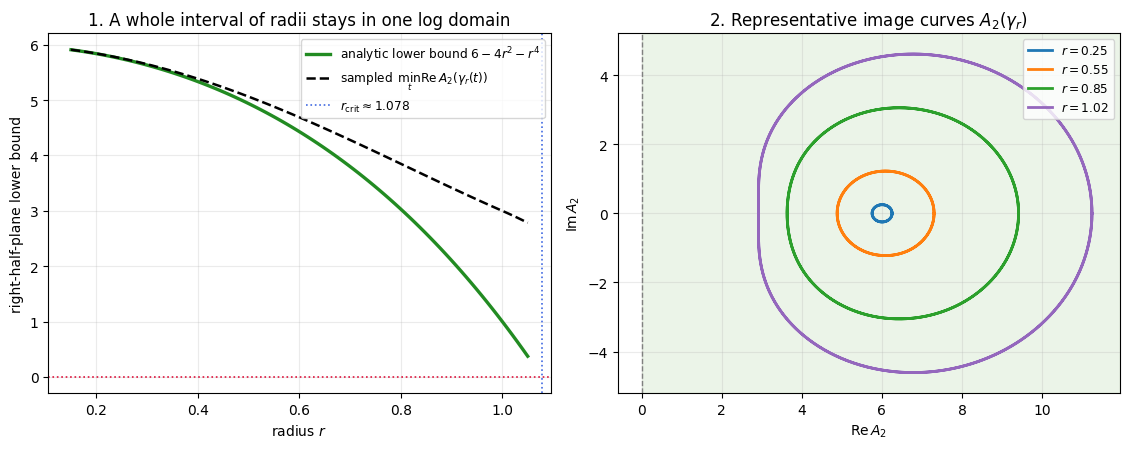

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6))

ax = axes[0]
ax.plot(r_values, right_half_lower_bound, color='forestgreen', lw=2.4,
        label=r'analytic lower bound $6-4r^2-r^4$')
ax.plot(r_values, min_re_sampled, color='black', lw=1.8, ls='--',
        label=r'sampled $\,\min_t \operatorname{Re} A_2(\gamma_r(t))$')
ax.axhline(0, color='crimson', lw=1.2, ls=':')
ax.axvline(r_crit, color='royalblue', lw=1.2, ls=':', label=rf'$r_{{\mathrm{{crit}}}} \approx {r_crit:.3f}$')
ax.set_xlabel(r'radius $r$')
ax.set_ylabel(r'right-half-plane lower bound')
ax.set_title(r'1. A whole interval of radii stays in one log domain')
ax.legend(loc='upper right', fontsize=8.7)

ax = axes[1]
curve_xmax = max(curve.real.max() for _, curve in representative_curves) + 0.7
ax.axvspan(0, curve_xmax, color='#d9ead3', alpha=0.5)
ax.axvline(0, color='gray', lw=1.0, ls='--')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
for color, (r, curve) in zip(colors, representative_curves):
    ax.plot(curve.real, curve.imag, color=color, lw=2.0, label=rf'$r={r:.2f}$')
ax.set_xlim(-0.6, curve_xmax)
all_im = np.concatenate([curve.imag for _, curve in representative_curves])
ax.set_ylim(all_im.min() - 0.6, all_im.max() + 0.6)
ax.set_xlabel(r'$\operatorname{Re} A_2$')
ax.set_ylabel(r'$\operatorname{Im} A_2$')
ax.set_title(r'2. Representative image curves $A_2(\gamma_r)$')
ax.legend(loc='upper right', fontsize=8.7)

plt.tight_layout()
plt.show()

#### Why this second example is useful

The first toy model exhibited one loop whose high-level image lies in one logarithm domain. This second example shows a family of loops with the same property: every radius in a nontrivial interval $0<r<r_{\mathrm{crit}}$ gives the same comparison mechanism.

The open point in Step 13 is therefore not the existence of examples. It is the branch-comparison statement for the actual high-level chains without assuming in advance that the image lies in one global logarithm domain.


### Geometric proof outline following the constructed examples

The plotted examples above suggest the same proof mechanism as in the main PLAN 08 notebook, but now focused on the exact Step 13 frontier.

| Constructed object in the plots | General mathematical object | Role in the proof |
|---|---|---|
| loop in the $z$-plane | a continuous basin loop $\gamma:[0,1]\to \mathcal B_\infty(2)$ | the path along which the two branch systems must be compared |
| high-level image $A_K(\gamma)$ in the $w$-plane | the image curve $\Gamma_K := A_K\circ \gamma \subset \mathbf C^*$ | the curve on which holomorphic continuation takes place |
| tubular neighborhoods around short arc segments | a finite consecutive simply-connected cover $U_1,\dots,U_m$ of $\Gamma_K$ | domains on which local logarithm branches are defined |
| highlighted overlap arc | a nonempty open overlap $V_j \subset U_j\cap U_{j+1}$ meeting $\Gamma_K$ | where equality of branches is transferred from one chart to the next |
| continued branch curve in the log-plane | the holomorphic continuation of the normalized starting germ | the common branch obtained after gluing the local branches |
| endpoint multiplier on $S^1$ | the final multiplier read from the endpoint logarithm value | the invariant that must agree for the actual and canonical continuations |
| one-parameter family $\gamma_r$ | an open regime of loops for which one global logarithm domain already exists | evidence that the Step 13 statement is geometrically natural and stable |

#### Proof skeleton

1. **Choose a sufficiently high escaping level $K$.** At this level the image curve lies in $\mathbf C^*$ and the canonical near-infinity continuation is already defined.
2. **Form the high-level image curve.** Set
   $$
   \Gamma_K := A_K(\gamma([0,1])) \subset \mathbf C^*.
   $$
3. **Choose a finite consecutive simply-connected cover.** Cover $\Gamma_K$ by open sets
   $$
   U_1,\dots,U_m \subset \mathbf C^*
   $$
   so that consecutive sets overlap along pieces of the curve.
4. **Attach the two branch systems.** On each $U_j$, let
   $$
   b_j^{\mathrm{act}}, \qquad b_j^{\mathrm{can}}
   $$
   be the local holomorphic logarithm branches coming respectively from the actual high-level construction and the canonical one-chart construction.
5. **Normalize at the starting germ.** Require that both systems start from the same branch value at the initial point of the curve.
6. **Use internal compatibility inside each system.** On every consecutive overlap, the actual branches glue to each other and the canonical branches glue to each other, because each system is itself a holomorphic continuation along the curve.
7. **Prove cross-system equality on overlaps.** Show that on each overlap, the actual branch and the canonical branch agree in a neighborhood of the overlap point. In the positive examples above this is immediate because both are restrictions of one holomorphic logarithm branch on the right half-plane.
8. **Propagate by the identity principle.** Once equality is known on one chart and on the next overlap, the identity principle forces equality on the next entire chart. Inductively, the two continuation procedures define the same holomorphic continuation along all of $\Gamma_K$.
9. **Read off the endpoint multiplier.** The terminal logarithm values coincide, hence the endpoint multipliers coincide. Since the canonical one-chart continuation has trivial high-level multiplier, the actual high-level continuation also has trivial multiplier.

#### What the positive examples show

The small-loop example shows a single concrete situation in which Step 13 is easy because one global logarithm domain contains the whole high-level image. The one-parameter family $\gamma_r$ shows that this is not an isolated accident: there is an open family of loops for which the same mechanism works. The remaining Step 13 work is therefore not the lack of examples; it is the absence of a theorem proving the same overlap-agreement conclusion for the **actual** high-level branch systems in general.


### Concrete construction in the spaces where the objects live

The geometric proof outline is clearer when the objects are shown in the spaces where they actually live:

1. the **$z$-plane**, where the basin loop $\gamma$ lives;
2. the **$w$-plane**, where the high-level image curve $A_2(\gamma)$ and the local neighborhoods $U_j$ live;
3. the **log-plane**, where the continued logarithm values live;
4. the **unit circle**, where the endpoint multiplier is read off.

The next plots follow exactly this construction for the toy model $\gamma(t)=\tfrac12 e^{2\pi i t}$.

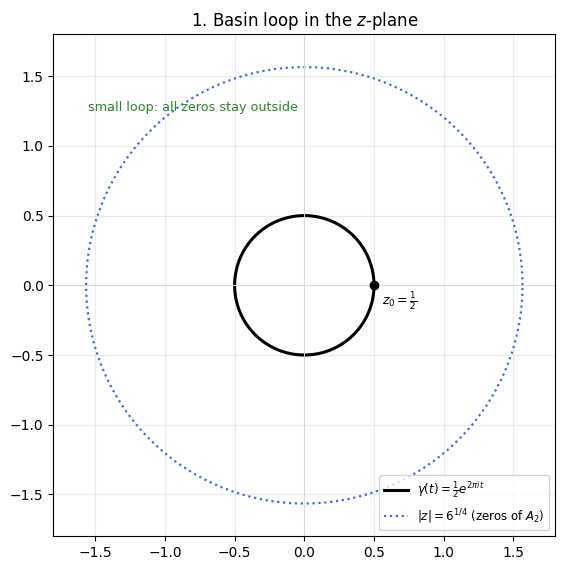

In [8]:
fig, ax = plt.subplots(figsize=(6.0, 5.8))
ax.set_aspect('equal')
theta = np.linspace(0, 2*np.pi, 500)
ax.plot(z_curve.real, z_curve.imag, color='black', lw=2.2,
        label=r'$\gamma(t)=\frac{1}{2}e^{2\pi i t}$')
ax.plot(zero_radius*np.cos(theta), zero_radius*np.sin(theta), color='royalblue', ls=':', lw=1.6,
        label=r'$|z|=6^{1/4}$ (zeros of $A_2$)')
ax.plot([gamma(0).real], [gamma(0).imag], 'ko', ms=6, zorder=5)
ax.text(gamma(0).real + 0.06, gamma(0).imag - 0.14, r'$z_0=\frac{1}{2}$', fontsize=9)
ax.text(-1.55, 1.25, r'small loop: all zeros stay outside', fontsize=9.2, color='forestgreen')
ax.axhline(0, color='0.85', lw=0.7)
ax.axvline(0, color='0.85', lw=0.7)
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_title(r'1. Basin loop in the $z$-plane')
ax.legend(loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.show()

#### 1. Basin loop in the $z$-plane

The construction starts from the loop
$$
\gamma(t)=\tfrac12 e^{2\pi i t}
$$
with starting point $z_0=\tfrac12$. The dotted circle marks the zero-set radius $|z|=6^{1/4}$ of
$$
A_2(z)=z^4+4z^2+6.
$$
Because this loop is small, all zeros of $A_2$ stay well outside it. This is the geometric reason the high-level image does **not** wind around $0$ in this toy model.

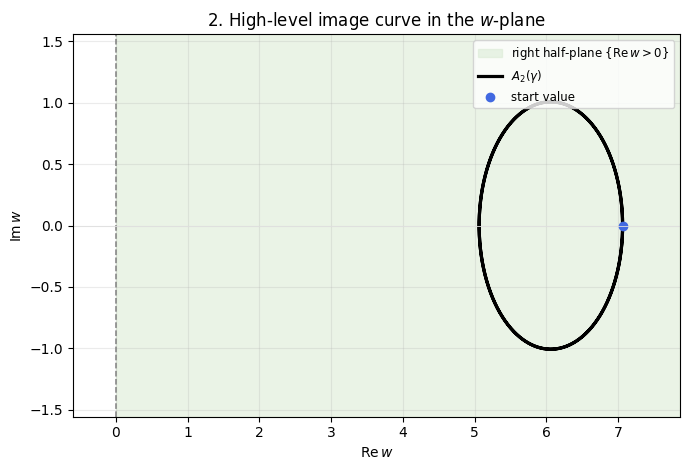

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.axvspan(0, float(w_curve.real.max()+0.8), color='#d9ead3', alpha=0.55,
           label=r'right half-plane $\{\operatorname{Re}w>0\}$')
ax.axvline(0, color='gray', lw=1.1, ls='--')
ax.plot(w_curve.real, w_curve.imag, color='black', lw=2.3, label=r'$A_2(\gamma)$')
ax.plot([w_curve[0].real], [w_curve[0].imag], 'o', ms=6, color='royalblue', label='start value')
ax.axhline(0, color='0.88', lw=0.6)
ax.set_xlim(-0.6, float(w_curve.real.max()+0.8))
ax.set_ylim(float(w_curve.imag.min()-0.55), float(w_curve.imag.max()+0.55))
ax.set_xlabel(r'$\operatorname{Re} w$')
ax.set_ylabel(r'$\operatorname{Im} w$')
ax.set_title(r'2. High-level image curve in the $w$-plane')
ax.legend(loc='upper right', fontsize=8.5)
plt.tight_layout()
plt.show()

#### 2. Image curve in the $w$-plane

Applying $A_2$ to the loop produces the actual curve along which the logarithm branches must be compared. In this example the whole image lies in the right half-plane, so one holomorphic logarithm branch already exists on a single open domain containing the entire curve.

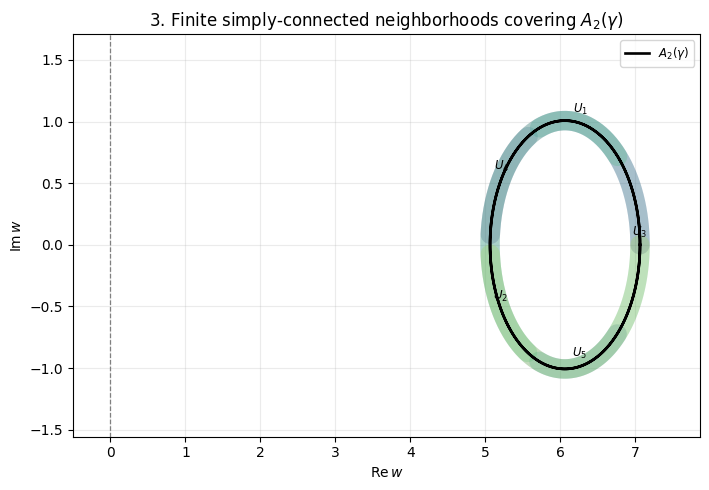

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
n_sets = 5
edges = np.linspace(0, len(w_curve)-1, n_sets+1, dtype=int)
pad = 60
for j in range(n_sets):
    a = max(0, edges[j] - pad)
    b = min(len(w_curve)-1, edges[j+1] + pad)
    seg = w_curve[a:b+1]
    color = plt.cm.viridis(0.15 + 0.7 * j / max(1, n_sets-1))
    ax.plot(seg.real, seg.imag, color=color, lw=14, alpha=0.24, solid_capstyle='round')
    mid = w_curve[(edges[j] + edges[j+1]) // 2]
    ax.text(mid.real, mid.imag + 0.08, rf'$U_{{{j+1}}}$', fontsize=8.5, ha='center')
ax.plot(w_curve.real, w_curve.imag, color='black', lw=1.9, label=r'$A_2(\gamma)$')
ax.axvline(0, color='gray', lw=0.9, ls='--')
ax.set_xlim(-0.5, float(w_curve.real.max()+0.8))
ax.set_ylim(float(w_curve.imag.min()-0.55), float(w_curve.imag.max()+0.7))
ax.set_xlabel(r'$\operatorname{Re} w$')
ax.set_ylabel(r'$\operatorname{Im} w$')
ax.set_title(r'3. Finite simply-connected neighborhoods covering $A_2(\gamma)$')
ax.legend(loc='upper right', fontsize=8.5)
plt.tight_layout()
plt.show()

#### 3. Finite simply-connected cover in the $w$-plane

Even though this toy model already has one global logarithm domain, it is useful to draw the finite-cover picture explicitly. The translucent tubular regions represent simply-connected open neighborhoods
$$
U_1,\dots,U_m \subset \mathbf C^*
$$
covering the image curve. This is the same kind of local data that appears in the general Step 13 theorem.

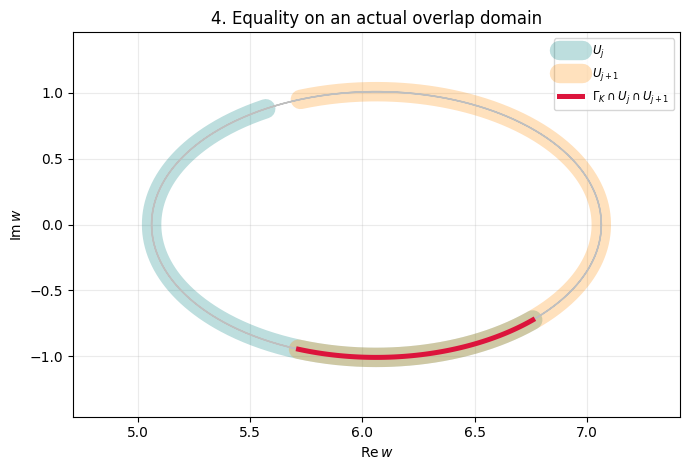

In [11]:
k = 1
a1 = max(0, edges[k] - pad)
b1 = min(len(w_curve)-1, edges[k+1] + pad)
a2 = max(0, edges[k+1] - pad)
b2 = min(len(w_curve)-1, edges[k+2] + pad)
seg1 = w_curve[a1:b1+1]
seg2 = w_curve[a2:b2+1]
interval1 = np.zeros(len(w_curve), dtype=bool)
interval2 = np.zeros(len(w_curve), dtype=bool)
interval1[a1:b1+1] = True
interval2[a2:b2+1] = True
overlap_mask = interval1 & interval2

fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.plot(seg1.real, seg1.imag, color='teal', lw=14, alpha=0.26, solid_capstyle='round', label=r'$U_j$')
ax.plot(seg2.real, seg2.imag, color='darkorange', lw=14, alpha=0.26, solid_capstyle='round', label=r'$U_{j+1}$')
ax.plot(w_curve.real, w_curve.imag, color='0.75', lw=1.1)
ax.plot(w_curve[overlap_mask].real, w_curve[overlap_mask].imag, color='crimson', lw=3.6,
        label=r'$\Gamma_K\cap U_j\cap U_{j+1}$')
ax.set_xlim(min(seg1.real.min(), seg2.real.min()) - 0.35,
            max(seg1.real.max(), seg2.real.max()) + 0.35)
ax.set_ylim(min(seg1.imag.min(), seg2.imag.min()) - 0.45,
            max(seg1.imag.max(), seg2.imag.max()) + 0.45)
ax.set_xlabel(r'$\operatorname{Re} w$')
ax.set_ylabel(r'$\operatorname{Im} w$')
ax.set_title(r'4. Equality on an actual overlap domain')
ax.legend(loc='upper right', fontsize=8.5)
plt.tight_layout()
plt.show()

#### 4. Equality on an actual overlap domain

The red arc is the part of the curve lying in the actual overlap
$$
U_j\cap U_{j+1}.
$$
This is the theorem-critical location. The remaining Step 13 statement is precisely that the actual branch and the canonical branch agree on a neighborhood of such overlap points. In the toy model this is immediate because both are restrictions of the principal logarithm on the right half-plane.

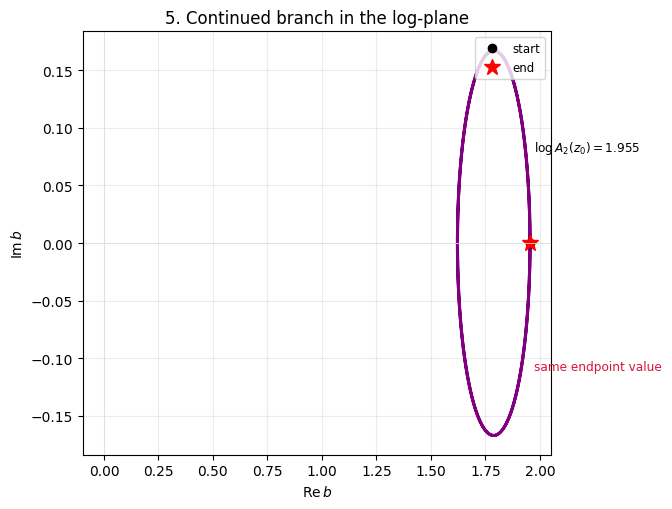

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.plot(log_curve.real, log_curve.imag, color='purple', lw=2.2)
ax.plot([log_curve.real[0]], [log_curve.imag[0]], 'ko', ms=6, label='start')
ax.plot([log_curve.real[-1]], [log_curve.imag[-1]], 'r*', ms=12, label='end')
ax.text(log_curve.real[0] + 0.02, log_curve.imag[0] + 0.08,
        rf'$\log A_2(z_0) = {np.log(abs(w_curve[0])):.3f}$', fontsize=8.7)
ax.text(log_curve.real[-1] + 0.02, log_curve.imag[-1] - 0.11,
        r'same endpoint value', fontsize=8.7, color='crimson')
ax.axhline(0, color='0.88', lw=0.6)
ax.axvline(0, color='0.88', lw=0.6)
ax.set_xlabel(r'$\operatorname{Re} b$')
ax.set_ylabel(r'$\operatorname{Im} b$')
ax.set_title(r'5. Continued branch in the log-plane')
ax.legend(loc='upper right', fontsize=8.5)
plt.tight_layout()
plt.show()

#### 5. The continued branch in the log-plane

The holomorphic continuation itself lives in the log-plane:
$$
b(t)=\log|A_2(\gamma(t))| + i\,\arg_{\mathrm{cont}}(A_2(\gamma(t))).
$$
For this small loop the continuation returns to the same logarithm value, because the image curve never encircles $0$. If the actual and canonical systems agree on each overlap, then they trace this same curve and therefore have the same endpoint in general.

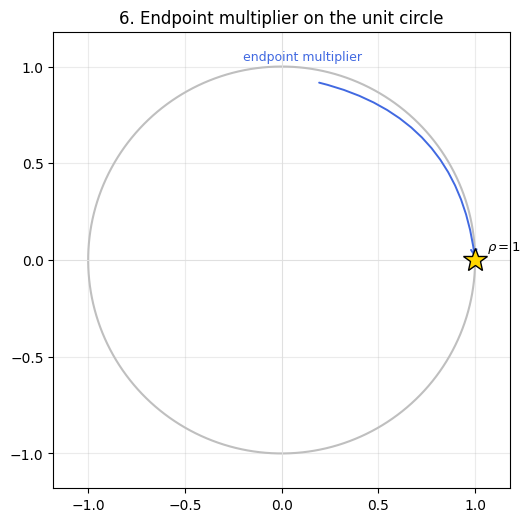

In [13]:
fig, ax = plt.subplots(figsize=(5.4, 5.4))
u = np.linspace(0, 2*np.pi, 400)
ax.set_aspect('equal')
ax.plot(np.cos(u), np.sin(u), color='0.75', lw=1.5)
ax.axhline(0, color='0.88', lw=0.7)
ax.axvline(0, color='0.88', lw=0.7)
ax.plot([endpoint_multiplier.real], [endpoint_multiplier.imag], marker='*', color='gold', mec='black', ms=18, zorder=5)
ax.text(endpoint_multiplier.real + 0.06, endpoint_multiplier.imag + 0.05, r'$\rho=1$', fontsize=9.5)
ax.annotate('', xy=(endpoint_multiplier.real, endpoint_multiplier.imag), xytext=(0.18, 0.92),
            arrowprops=dict(arrowstyle='->', lw=1.4, color='royalblue', connectionstyle='arc3,rad=-0.35'))
ax.text(-0.2, 1.03, r'endpoint multiplier', fontsize=9.0, color='royalblue')
ax.set_xlim(-1.18, 1.18)
ax.set_ylim(-1.18, 1.18)
ax.set_title(r'6. Endpoint multiplier on the unit circle')
plt.tight_layout()
plt.show()

#### 6. Endpoint multiplier on the unit circle

The endpoint multiplier is read in
$$
S^1 = \{e^{i\theta}:\theta\in\mathbf R\}.
$$
In this toy model the terminal logarithm value has the same imaginary part as the initial one, so the multiplier is
$$
\rho = 1.
$$
This is exactly the last step of the general argument: once the actual and canonical continuations have the same endpoint logarithm value, they have the same endpoint multiplier.

### Rigorous proof of the comparison theorem in the generalized setting

The geometric outline above leads to the following exact comparison statement.

**Theorem (comparison from holomorphic logarithm branches along a finite cover).**
Let
$$
\Gamma:[0,1]\to \mathbf C^*
$$
be a continuous path, and let
$$
0=t_0<t_1<\cdots<t_m=1
$$
be a partition. Let
$$
U_1,\dots,U_m \subset \mathbf C^*
$$
be connected open sets such that
$$
\Gamma([t_{j-1},t_j])\subset U_j \qquad (1\le j\le m).
$$
Assume that for each $1\le j<m$ there exists a nonempty open set
$$
V_j \subset U_j\cap U_{j+1}
$$
containing a neighborhood of the overlap point $\Gamma(t_j)$ along the curve.

For each $j$, let
$$
b_j^{\mathrm{act}},\; b_j^{\mathrm{can}}:U_j\to \mathbf C
$$
be holomorphic functions satisfying
$$
\exp\bigl(b_j^{\mathrm{act}}\bigr)=\exp\bigl(b_j^{\mathrm{can}}\bigr)=\operatorname{id}_{U_j}.
$$
Assume:

1. **same initial germ:**
   $$
   b_1^{\mathrm{act}}(\Gamma(0)) = b_1^{\mathrm{can}}(\Gamma(0));
   $$
2. **internal compatibility of the actual system:** for each $1\le j<m$,
   $$
   b_{j+1}^{\mathrm{act}} = b_j^{\mathrm{act}} \quad \text{on } V_j;
   $$
3. **internal compatibility of the canonical system:** for each $1\le j<m$,
   $$
   b_{j+1}^{\mathrm{can}} = b_j^{\mathrm{can}} \quad \text{on } V_j.
   $$

Then:

1. for every $j$,
   $$
   b_j^{\mathrm{act}} = b_j^{\mathrm{can}} \quad \text{on } U_j;
   $$
2. the endpoint logarithm values coincide:
   $$
   b_m^{\mathrm{act}}(\Gamma(1)) = b_m^{\mathrm{can}}(\Gamma(1));
   $$
3. consequently, any endpoint multiplier extracted from these terminal logarithm values is the same for the actual and canonical continuation procedures.

**Proof.**
We prove by induction on $j$ that
$$
b_j^{\mathrm{act}} = b_j^{\mathrm{can}} \quad \text{on } U_j.
$$

For $j=1$, consider the difference
$$
d_1 := b_1^{\mathrm{act}} - b_1^{\mathrm{can}}.
$$
This is holomorphic on the connected open set $U_1$, and
$$
\exp(d_1)=\frac{\exp(b_1^{\mathrm{act}})}{\exp(b_1^{\mathrm{can}})}=1.
$$
Hence
$$
d_1(U_1) \subset 2\pi i\mathbf Z.
$$
Since $U_1$ is connected and $d_1$ is continuous, the image $d_1(U_1)$ is connected. The only connected subsets of the discrete set $2\pi i\mathbf Z$ are singletons. Therefore $d_1$ is constant. By the initial normalization,
$$
d_1(\Gamma(0)) = 0,
$$
so $d_1\equiv 0$ on $U_1$. Thus
$$
b_1^{\mathrm{act}} = b_1^{\mathrm{can}} \quad \text{on } U_1.
$$

Now assume for some $j<m$ that
$$
b_j^{\mathrm{act}} = b_j^{\mathrm{can}} \quad \text{on } U_j.
$$
On the nonempty open set $V_j\subset U_j\cap U_{j+1}$ we have, by the compatibility assumptions,
$$
b_{j+1}^{\mathrm{act}} = b_j^{\mathrm{act}} = b_j^{\mathrm{can}} = b_{j+1}^{\mathrm{can}}.
$$
Thus the two holomorphic functions $b_{j+1}^{\mathrm{act}}$ and $b_{j+1}^{\mathrm{can}}$ on the connected open set $U_{j+1}$ agree on the nonempty open subset $V_j$. By the identity principle,
$$
b_{j+1}^{\mathrm{act}} = b_{j+1}^{\mathrm{can}} \quad \text{on } U_{j+1}.
$$
This completes the induction.

Therefore
$$
b_m^{\mathrm{act}}(\Gamma(1)) = b_m^{\mathrm{can}}(\Gamma(1)).
$$
Any endpoint multiplier obtained by exponentiating the imaginary part, or equivalently by comparing the terminal logarithm value with the initial normalized germ, is therefore the same for the two continuation procedures. This proves the theorem. $\square$

#### Interpretation for the Step 13 frontier

In the frontier problem, the path is the high-level image curve
$$
\Gamma_K = A_K\circ \gamma,
$$
and the remaining theorem is to construct the sets $U_j$, the overlap neighborhoods $V_j$, and the two branch systems so that the three hypotheses above hold. Once this is done, equality of the actual and canonical high-level endpoint multipliers is immediate.

The positive examples above are precisely the cases in which these hypotheses hold for a simple geometric reason: all local branches come from one holomorphic logarithm on the same right-half-plane domain. The remaining Step 13 work is to prove an analogous statement for the high-level continuation data without assuming in advance that one global logarithm domain already contains the whole curve.


## What has to be shown about the actual branches

For each adjacent overlap in the actual high-level chart chain, one has to prove that the actual local logarithm branch and the canonical branch agree on a neighborhood of the overlap value after normalizing the same starting germ.

In concrete terms, the remaining work is:

1. construct the actual high-level charts for the chosen escaping level;
2. define the local logarithm branches on those charts;
3. prove agreement with the canonical punctured-plane branch near each overlap value;
4. prove compatibility of these comparisons along the whole finite chain.

This is the remaining Step 13 statement.


## Relationship to the larger Böttcher route

This notebook records only the PLAN 08 part.

After Step 13, the result still has to be combined with escape-time-independent pullback data and the basin-extension package to reach:

```lean
MonodromyTrivialPullbackDataFor (2 : ℂ)
PrincipalPullbackCoherentDataFor (2 : ℂ)
LogSeriesBasinExtensionDataFor (2 : ℂ)
GenuineBottcherCoordinateDataFor (2 : ℂ)
```

The current Step 13 task is the high-level chain comparison theorem.
